In [1]:
#import important things

import matplotlib.pyplot as plt
import rebound
import numpy as np
import pandas as pd
import scipy
import math
import random
from scipy.optimize import minimize
#from scipy.integrate import solve_ivp, odeint
from scipy.signal import find_peaks

In [2]:
def setup_tri(j, k, mutot, etilde, pomega2, lambda_target, ind, iterations = 20):
    ecross = 2*k/(3*j)
    n1 = 2*np.pi
    n2 = n1*(j-k)/j
    tconj = 2*np.pi/(n1-n2) # estimate for time between conjunctions
    t0 = -0.8*tconj

    lambda10 = lambda_target+n1*t0 # this should be exact since 
    lambda20 = lambda_target+n2*t0

    setupSim=rebound.Simulation()
    setupSim.add(m=1)
    
    if ind == 1:
        setupSim.add(P=j/(j-k), e=etilde*ecross, pomega=pomega2, l=lambda_target)
        x_target = setupSim.particles[1].x
    else:
        setupSim.add(P=1, e=etilde*ecross, pomega=pomega2, l=lambda_target)
        x_target = setupSim.particles[1].x

    if ind == 1: #inner pair
        lambda_20_prev = lambda20 # initial guess
        correction = 0
        for i in range(iterations):
            lambda_20 = lambda_20_prev + correction
            sim = rebound.Simulation()
            sim.add(m=1)
            sim.add(primary=sim.particles[0], m=mutot, P=1, l=lambda10)
            sim.add(primary=sim.particles[0], P=j/(j-k), e=etilde*ecross, pomega=pomega2, l=lambda_20)
            var_l = sim.add_variation()
            var_l.vary(2, 'l') # how does everything depend on the initial l of particles[2]
            sim.t = t0
            ps = sim.particles
            
            sim.integrate(0)
            correction = (x_target - ps[2].x)/var_l.particles[2].x
            lambda_20_prev = lambda_20
            #print('***',i,'***')
            #print(lambda_20_prev, ps[2].l, lambda_target-ps[2].l, correction)
        
       
        lambda_20 = lambda_20_prev + correction
        sim = rebound.Simulation()
        sim.add(m=1)
        sim.add(primary=sim.particles[0], m=mutot, P=1, l=lambda10)
        sim.add(primary=sim.particles[0], P=j/(j-k), e=etilde*ecross, pomega=pomega2, l=lambda_20)
    else: #outer pair
        lambda_10_prev = lambda10 # initial guess
        correction = 0
        for i in range(iterations):
            lambda_10 = lambda_10_prev + correction
            sim = rebound.Simulation()
            sim.add(m=1)
            sim.add(primary=sim.particles[0],P=1,e=etilde*ecross, pomega=pomega2, l=lambda_10)
            sim.add(primary=sim.particles[0],m=mutot, P=j/(j-k), l=lambda20)
            var_l = sim.add_variation()
            var_l.vary(1, 'l') # how does everything depend on the initial l of particles[2]
            sim.t = t0
            ps = sim.particles
        
            sim.integrate(0)
            correction = (x_target - ps[1].x)/var_l.particles[1].x
            lambda_10_prev = lambda_10
            #print('***',i,'***')
            #print(lambda_10_prev, ps[2].l, lambda_target-ps[2].l, correction)
        
       
        lambda_10 = lambda_10_prev + correction
        sim = rebound.Simulation()
        sim.add(m=1)
        sim.add(primary=sim.particles[0], P=1,e=etilde*ecross, pomega=pomega2, l=lambda_10)
        sim.add(primary=sim.particles[0], m=mutot, P=j/(j-k), l=lambda20)
    sim.t = t0
    return sim

In [3]:
def unwrap_l(ps):
    ''' given a sim.particles object ps, returns relative lambda (l) value of the planets
        removing the 2*pi discontinuities that result when one planet has crossed l=0 but
        the other has not
    '''
    if ps[2].l - ps[1].l > np.pi:
        return ps[2].l - ps[1].l - 2*np.pi
    elif ps[2].l - ps[1].l < -np.pi:
        return ps[2].l - ps[1].l + 2*np.pi
    else:
        return ps[2].l - ps[1].l

In [4]:
def new_run(sim, Nconj, Nout, ind):
    '''
    This function runs the Nbody simulation until we get Nconj conjunctions 
    and save the orbital parameters and conjunction times.
    '''
    # this function now saves individual semimajor axis length and other individual variables (will keep adding)
    ps = sim.particles
    n1 = ps[1].n
    n2 = ps[2].n
    tmin = sim.t
    #print(tmin)
    tconj = 2*np.pi/(n1-n2)
    tmax = Nconj*tconj + 0.8*tmin

    a12_arr, l12_arr, l2, theta_arr, pomega_arr, e12_arr, diffn_arr = np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout)
    e1, e2, pomega1, pomega2, a1_arr, a2_arr = np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout)
    n1_arr, n2_arr = np.zeros(Nout), np.zeros(Nout)
    l1 = np.zeros(Nout)
    times = np.linspace(tmin, tmax, Nout)
    #print(times)
    for i, time in enumerate(times):
        if ind==1:
            a12_arr[i] = (ps[2].a - ps[1].a)/ps[1].a # relative semimajor axis (a-a_p)/a_p
        else:
            a12_arr[i] = (ps[1].a - ps[2].a)/ps[2].a # now the second index is the planet
        a1_arr[i] = ps[1].a
        a2_arr[i] = ps[2].a
        l12_arr[i] = unwrap_l(ps) 
        e1_vec_temp= ps[1].e * np.exp(1j * ps[1].pomega)
        e2_vec_temp= ps[2].e * np.exp(1j * ps[2].pomega)
        if ind==1:
            pomega12_temp = np.angle(e2_vec_temp-e1_vec_temp)
            e12_temp = np.abs(e2_vec_temp-e1_vec_temp)
        else:
            pomega12_temp = np.angle(e1_vec_temp-e2_vec_temp)
            e12_temp = np.abs(e1_vec_temp-e2_vec_temp)
        theta_arr[i] = ps[2].l - pomega12_temp

        l1[i] = ps[1].l
        l2[i] = ps[2].l
        pomega_arr[i] = pomega12_temp
        e12_arr[i] = e12_temp

        n1_arr[i] = ps[1].n
        n2_arr[i] = ps[2].n
        e1[i] = ps[1].e
        e2[i] = ps[2].e
        pomega1[i] = ps[1].pomega
        pomega2[i] = ps[2].pomega
        diffn_arr[i] = ps[1].n - ps[2].n
        sim.integrate(time)

    l1 = np.unwrap(l1)
    l2 = np.unwrap(l2)
    
    # conjunctions occur at minima pf dl = maxima of -dl
    conj_idx, _ = find_peaks(-np.abs(l12_arr))
    if len(conj_idx) != Nconj:
        print("WARNING: wrong number of conjunction events found \n {} conjunctions found, {} conjunctions input".format(len(conj_idx), Nconj))
        #raise Exception('''wrong number of conjunction events found \n {} conjunctions found, 
        #                {} conjunctions input'''.format(len(conj_idx), Nconj))
    #pts_btwn_conj = (.5*np.diff(conj_idx)).astype(np.int64)

    btwn_conj_idx, properties = find_peaks(np.abs(l12_arr))
    #btwn_conj_idx[1:] = conj_idx[:-1] + pts_btwn_conj

    return [times, a12_arr, l12_arr, theta_arr, l1, l2, pomega_arr, e12_arr, e1, e2, pomega1, pomega2, diffn_arr, conj_idx, btwn_conj_idx, a1_arr, a2_arr, n1_arr, n2_arr]


In [5]:
def wrap_angles(angles):
    return (angles + np.pi) % (2 * np.pi) - np.pi

In [16]:
#Parameters and initial conditions
Nconj = 500 #number of conjunctions
Nout = Nconj*100
ind = 1# 1 for inner pair, 3 for outer pair
order = 1
# mapping order: 1 for first, 2 for second etc.

0.05555555555555555
0.005555555555555556


In [7]:
#Namouni mapping setup
W1, W2, W3, W4, W200 = 3.359350011, -2.678665722, 2.639498803, -2.8559, -1 #constants from the expansion
W301 = 0.1430675142
W402 = 0.5232506456
W400 = -3/8
g = 2.23956667
#%% Namouni Mapping Functions
def calc_coeff(q, Wq, ar, theta):
    """Coefficient for power series in Namouni for the q'th order (derivatives of W wrt phi)."""
    return 2*q*2**(q/2)*Wq*np.sin(2*theta)/ar**(q+1)

def namouni_fo_step(In, Kn, phin, lambdan, arn, ind):
    """First-order Namouni mapping step."""
    hn = np.sqrt(2*In)*np.cos(phin)
    kn = np.sqrt(2*In)*np.sin(phin)
    if ind == 1:
        hprime = hn + 2*W1*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
        kprime = kn - 2*W1*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
    else: #from DQT, the sign switches for the outer pair
        hprime = hn + 2*W1*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
        kprime = kn - 2*W1*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
    phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
    #print(hn, kn)
    # both options should give the same result:
    Inprime = 1/2*(hprime**2 + kprime**2)
    #Inprime = In + 2*W1/arn**2*np.sqrt(2*In)*np.sin(thetan) + 2*W1**2/arn**4
    #Namouni update
    hnp1 = hprime
    knp1 = kprime
    Inp1 = Inprime
    Knp1 = Kn + Inp1 - In
    phinp1 = phiprime
    #lambdanp1 = lambdan + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))
    lambdanp1 = lambdan + 2*np.pi*np.abs(1/((1+np.sqrt(8*Knp1/3)*epsilon)**(-3/2)-1)) #same lambda
    
    return Inp1, Knp1, phinp1, lambdanp1, hnp1, knp1

def namouni_so_step(In, Kn, phin, lambdan, arn, ind):
    """Second-order Namouni mapping step."""
    hn = np.sqrt(2*In)*np.cos(phin)
    kn = np.sqrt(2*In)*np.sin(phin)
    if ind == 1:
        hprime = hn + 2*W1*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
        kprime = kn - 2*W1*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
    else: #from DQT, the sign switches for the outer pair
        hprime = hn + 2*W1*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
        kprime = kn - 2*W1*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
    phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
    thetaprime = phiprime - lambdan

    # A = calc_coeff(2, W2, arn, thetaprime)
    # E1 = 1/(1+A)
    # Inp1 = E1*Inprime

    Inp1 = (0.5*(hprime**2 + kprime**2)) / (1 + 4*W2*np.sin(2*thetaprime)*2/arn**3)
    #print(np.mod(thetaprime, 2*np.pi)/np.pi, phiprime)
    #print(-np.mod(2*thetaprime, 2*np.pi)/np.pi, 0.5*(hprime**2 + kprime**2)-In, (Inp1-0.5*(hprime**2 + kprime**2))/Inp1, (1 + 4*W2*np.sin(-2*thetaprime)*2/arn**3))
    phinp1 = phiprime - (W200 + 2*W2*np.cos(2*thetaprime))*2/arn**3
    Knp1 = Kn + Inp1 - In
    #lambdanp1 = lambdan + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))
    lambdanp1 = lambdan + 2*np.pi*np.abs(1/((1+np.sqrt(8*Knp1/3)*epsilon)**(-3/2)-1)) #same lambda
    hnp1 = np.sqrt(2*Inp1)*np.cos(phinp1)
    knp1 = np.sqrt(2*Inp1)*np.sin(phinp1)
    return Inp1, Knp1, phinp1, lambdanp1, hnp1, knp1

In [8]:
def namouni_so_step_iter(In, Kn, phin, lambdan, arn, ind):
    """Second-order Namouni mapping step."""
    """The second order mapping involves an intermediate step and implicit scheme for eccentricity update."""
    """This calculates the implicit update iteratively instead of explicitly solving for the next value."""
    hn = np.sqrt(2*In)*np.cos(phin)
    kn = np.sqrt(2*In)*np.sin(phin)
    if ind == 1:
        hprime = hn + 2*W1*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
        kprime = kn - 2*W1*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
    else: #from DQT, the sign switches for the outer pair
        hprime = hn + 2*W1*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
        kprime = kn - 2*W1*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
    phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
    #thetaprime = (pomegaprime - lambdan)
    thetaprime = (phiprime - lambdan)

    # A = calc_coeff(2, W2, arn, thetaprime)
    # E1 = 1/(1+A)
    # Inp1 = E1*Inprime
    #implicit I update
    Iprime = 0.5*(hprime**2 + kprime**2)
    Inp1_prev = Iprime #first guess = Iprime
    while True: #iteratively update using implicit scheme
        Inp1_next = Iprime - 4*W2*np.sin(2*thetaprime)*2*Inp1_prev/arn**3
        if np.abs((Inp1_next-Inp1_prev)/Inp1_next) < 1e-12: #break when satisfied
            break
        Inp1_prev = Inp1_next
    # Inp1 = (0.5*(hprime**2 + kprime**2)) / (1 + 4*W2*np.sin(2*thetaprime)*2/arn**3)
    Inp1 = Inp1_next

    #pomeganp1 = pomegaprime - (W200 + 2*W2*np.cos(2*thetaprime))*2/arn**3
    pomeganp1 = phiprime - (W200 + 2*W2*np.cos(2*thetaprime))*2/arn**3
    Knp1 = Kn + Inp1 - In
    hnp1 = np.sqrt(2*Inp1)*np.cos(phinp1)
    knp1 = np.sqrt(2*Inp1)*np.sin(phinp1)
    #lambdanp1 = lambdan + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))
    lambdanp1 = lambdan + 2*np.pi*np.abs(1/((1+np.sqrt(8*Knp1/3)*epsilon)**(-3/2)-1)) #same lambda
    return Inp1, Knp1, phinp1, lambdanp1, hnp1, knp1

In [9]:
def namouni_4o_step(In, Kn, phin, lambdan, arn, ind):
    """Fourth-order Namouni mapping step."""
    """The fourth order mapping involves an intermediate step and implicit scheme for eccentricity update."""
    """This calculates the implicit update iteratively instead of explicitly solving for the next value."""
    hn = np.sqrt(2*In)*np.cos(phin)
    kn = np.sqrt(2*In)*np.sin(phin)
    if ind == 1:
        hprime = hn + 2*W1*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
        kprime = kn - 2*W1*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
    else: #from DQT, the sign switches for the outer pair
        hprime = hn + 2*W1*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
        kprime = kn - 2*W1*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
    phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
    #thetaprime = (pomegaprime - lambdan)
    thetaprime = (phiprime - lambdan)

    # A = calc_coeff(2, W2, arn, thetaprime)
    # E1 = 1/(1+A)
    # Inp1 = E1*Inprime
    #implicit I update
    Iprime = 0.5*(hprime**2 + kprime**2)
    Inp1_prev = Iprime #first guess = Iprime
    phinp1_prev = phiprime
    while True: #iteratively update using implicit scheme
        Inp1o2 = 4*W2*np.sin(2*thetaprime)*2*Inp1_prev/arn**3
        Inp1o3 = (2*W301*np.sin(thetaprime)+6*W3*np.sin(3*thetaprime))*(2*Inp1_prev)**(3/2)/arn**4
        Inp1o4 = (4*W402*np.sin(2*thetaprime)+8*W4*np.sin(4*thetaprime))*(2*Inp1_prev)**(2)/arn**5
        Inp1_next = Iprime - Inp1o2 - Inp1o3 - Inp1o4
        phinp1o2 = (W200 + 2*W2*np.cos(2*thetaprime))*2/arn**3
        phinp1o3 = 3*2**(3/2)*(W301*np.cos(thetaprime)+W3*np.cos(3*thetaprime))*Inp1_prev**0.5/arn**4
        phinp1o4 = 8*(W400+2*W402*np.cos(2*thetaprime)+2*W4*np.cos(4*thetaprime))*Inp1_prev/arn**5
        phinp1_next = phiprime - (phinp1o2+phinp1o3+phinp1o4)
        if np.abs((Inp1_next-Inp1_prev)/Inp1_next) < 1e-12 and np.abs((phinp1_next-phinp1_prev)/phinp1_next) < 1e-12: 
            #break when satisfied
            break
        Inp1_prev = Inp1_next
        phinp1_prev = phinp1_next
    # Inp1 = (0.5*(hprime**2 + kprime**2)) / (1 + 4*W2*np.sin(2*thetaprime)*2/arn**3)
    Inp1 = Inp1_next
    phinp1 = phinp1_next
    #pomeganp1 = pomegaprime - (W200 + 2*W2*np.cos(2*thetaprime))*2/arn**3
    Knp1 = Kn + Inp1 - In
    hnp1 = np.sqrt(2*Inp1)*np.cos(phinp1)
    knp1 = np.sqrt(2*Inp1)*np.sin(phinp1)
    #lambdanp1 = lambdan + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))
    lambdanp1 = lambdan + 2*np.pi*np.abs(1/((1+np.sqrt(8*Knp1/3)*epsilon)**(-3/2)-1)) #same lambda
    return Inp1, Knp1, phinp1, lambdanp1, hnp1, knp1

In [10]:
def namouni_o4_step_lizzy(In, Kn, lambdan, phin, ar0): #lizzy's version
    hn = np.sqrt(2*In)*np.cos(phin)
    kn = np.sqrt(2*In)*np.sin(phin)
    hprime = hn + 2*W1*np.sin(lambdan)/ar0**2 # + for Namouni, - for pomega
    kprime = kn - 2*W1*np.cos(lambdan)/ar0**2 # - for Namouni, + for pomega

    phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
    Inprime = 1/2*(hprime**2 + kprime**2)
    thetaprime = (phiprime - lambdan) % (2*np.pi)

    if thetaprime > np.pi:
            thetaprime = thetaprime - 2*np.pi

    Inp1_o2 = Inprime/(1+4*W2*np.sin((2*thetaprime))*2/ar0**3)  # 0 from W2 and -thetaprime cancels?
    Inp1_o3 = (Inprime - 4*W2*np.sin(2*thetaprime)*2/ar0**3*Inp1_o2 - 
               6*W3*np.sin(3*thetaprime)*(2*Inp1_o2)**(3/2)/ar0**4) # 3rd order 
    Inp1_o4 = (Inprime - 4*W2*np.sin(2*thetaprime)*2/ar0**3*Inp1_o3 - 
               6*W3*np.sin(3*thetaprime)*(2*Inp1_o3)**(3/2)/ar0**4 - 
               8*W4*np.sin(4*thetaprime)*(2*Inp1_o3)**(2)/ar0**5) # 4th order  
    phinp1 = phiprime - (W200 + 2*W2*np.cos(2*(thetaprime)))*2/ar0**3 - (W301 + .5232506456 + 2*W3*np.cos(3*(thetaprime)))*2**(3/2)/ar0**4 - (W400 + 2*W4*np.cos(4*(thetaprime)))*2**(2)/ar0**5


    A = calc_coeff(2, W2, ar0, thetaprime)
    B = calc_coeff(3, W3, ar0, thetaprime)
    C = calc_coeff(4, W4, ar0, thetaprime)
    E1 = 1/(1+A)
    E2 = -B#/(1+A)**5/2                  # from wolfram alpha
    E3 = (3*B**2 - 2*(1+A)*C)/(2*(1+A)**4)
    E3approx = -C# (3*B**2 - 2*C)/2


    Inp1_analytic = E1*Inprime + E2*Inprime**(3/2) + E3approx*Inprime**(2)

    Knp1 = Kn + Inp1_analytic-In
    #lambdanp1 = lambdan + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))
    lambdanp1 = lambdan + 2*np.pi*np.abs(1/((1+np.sqrt(8*Knp1/3)*epsilon)**(-3/2)-1)) #same lambda
    return Inp1_analytic, Knp1, phinp1, lambdanp1

In [11]:
def namouni_10o_step(In, Kn, phin, lambdan, arn, ind):
    """Tenth-order Namouni mapping step."""
    """The tenth order mapping involves an intermediate step and implicit scheme for eccentricity update."""
    """This calculates the implicit update iteratively instead of explicitly solving for the next value."""
    #define all coeffs in here so that we won't get confused
    #format WABC = W^{A,B}_C
    W200, W400, W600, W800, W1000 = -1,-3/8,-5/24,-35/256,-63/640
    W101, W301, W501, W701, W901 = 3.359350011, 0.1430675142, 0.2652528982, 0.1598760057, 0.1125398541
    W202, W402, W602, W802, W1002 = -2.678665722, 0.5232506456, -0.2880525893, -0.1146109541, -0.09264257446
    W303, W503, W703, W903 = 2.639498803, -1.270297850, 0.5079066956, 0.04027194541
    W404, W604, W804, W1004 = -2.855951527, 2.244981532, -1.030263325, 0.1370220235
    W505, W705, W905 = 3.259400253, -3.586274249, 2.034584646
    W606, W806, W1006 = -3.850815349, 5.467708834, -3.807558748
    W707, W907 = 4.661571101, -8.124434579
    W808, W1008 = -5.745863967, 11.88290720
    W909 = 7.181868977
    W10010 = -9.077037610
    
    hn = np.sqrt(2*In)*np.cos(phin)
    kn = np.sqrt(2*In)*np.sin(phin)
    if ind == 1:
        hprime = hn + 2*W1*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
        kprime = kn - 2*W1*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
    else: #from DQT, the sign switches for the outer pair
        hprime = hn + 2*W1*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
        kprime = kn - 2*W1*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
    phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
    #thetaprime = (pomegaprime - lambdan)
    thetaprime = (phiprime - lambdan)

    # A = calc_coeff(2, W2, arn, thetaprime)
    # E1 = 1/(1+A)
    # Inp1 = E1*Inprime
    #implicit I update
    Iprime = 0.5*(hprime**2 + kprime**2)
    Inp1_prev = np.float64(Iprime) #first guess = Iprime
    phinp1_prev = np.float64(phiprime)
    while True: #iteratively update using implicit scheme
        Inp1o1 = 2*(W301/arn**4*(2*Inp1_prev)**1.5+W501/arn**6*(2*Inp1_prev)**2.5+W701/arn**8*(2*Inp1_prev)**3.5+W901/arn**10*(2*Inp1_prev)**4.5)*np.sin(thetaprime)
        Inp1o2 = 4*(W202/arn**3*(2*Inp1_prev)+W402/arn**5*(2*Inp1_prev)**2+W602/arn**7*(2*Inp1_prev)**3+W802/arn**9*(2*Inp1_prev)**4+W1002/arn**11*(2*Inp1_prev)**5)*np.sin(2*thetaprime)
        Inp1o3 = 6*(W303/arn**4*(2*Inp1_prev)**1.5+W503/arn**6*(2*Inp1_prev)**2.5+W703/arn**8*(2*Inp1_prev)**3.5+W903/arn**10*(2*Inp1_prev)**4.5)*np.sin(3*thetaprime)
        Inp1o4 = 8*(W404/arn**5*(2*Inp1_prev)**2+W604/arn**7*(2*Inp1_prev)**3+W804/arn**9*(2*Inp1_prev)**4+W1004/arn**11*(2*Inp1_prev)**5)*np.sin(4*thetaprime)
        Inp1o5 = 10*(W505/arn**6*(2*Inp1_prev)**2.5+W705/arn**8*(2*Inp1_prev)**3.5+W905/arn**10*(2*Inp1_prev)**4.5)*np.sin(5*thetaprime)
        Inp1o6 = 12*(W606/arn**7*(2*Inp1_prev)**3+W806/arn**9*(2*Inp1_prev)**4+W1006/arn**11*(2*Inp1_prev)**5)*np.sin(6*thetaprime)
        Inp1o7 = 14*(W707/arn**8*(2*Inp1_prev)**3.5+W907/arn**10*(2*Inp1_prev)**4.5)*np.sin(7*thetaprime)
        Inp1o8 = 16*(W808/arn**9*(2*Inp1_prev)**4+W1008/arn**11*(2*Inp1_prev)**5)*np.sin(8*thetaprime)
        Inp1o9 = 18*(W909/arn**10*(2*Inp1_prev)**4.5)*np.sin(9*thetaprime)
        Inp1o10 = 20*(W10010/arn**11*(2*Inp1_prev)**5)*np.sin(10*thetaprime)
        Inp1_next = Iprime -Inp1o2-Inp1o3-Inp1o4-Inp1o5-Inp1o6-Inp1o7-Inp1o8-Inp1o9-Inp1o10
        phinp1o0 = W200*2/arn**3+W400*2**2*2*Inp1_prev/arn**5+W600*2**3*3*Inp1_prev**2/arn**7+W800*2**4*4*Inp1_prev**3/arn**9+W1000*2**5*5*Inp1_prev**4/arn**11
        phinp1o1 = 2*(W301*2**1.5*1.5*Inp1_prev**0.5/arn**4+W501*2**2.5*2.5*Inp1_prev**1.5/arn**6+W701*2**3.5*3.5*Inp1_prev**2.5/arn**8+W901*2**4.5*4.5*Inp1_prev**3.5/arn**10)*np.cos(thetaprime)
        phinp1o2 = 2*(W202*2/arn**3+W402*2**2*2*Inp1_prev/arn**5+W602*2**3*3*Inp1_prev**2/arn**7+W802*2**4*4*Inp1_prev**3/arn**9+W1002*2**5*5*Inp1_prev**4/arn**11)*np.cos(2*thetaprime)
        phinp1o3 = 2*(W303*2**1.5*1.5*Inp1_prev**0.5/arn**4+W503*2**2.5*2.5*Inp1_prev**1.5/arn**6+W703*2**3.5*3.5*Inp1_prev**2.5/arn**8+W903*2**4.5*4.5*Inp1_prev**3.5/arn**10)*np.cos(3*thetaprime)
        phinp1o4 = 2*(W404*2**2*2*Inp1_prev/arn**5+W604*2**3*3*Inp1_prev**2/arn**7+W804*2**4*4*Inp1_prev**3/arn**9+W1004*2**5*5*Inp1_prev**4/arn**11)*np.cos(4*thetaprime)
        phinp1o5 = 2*(W505*2**2.5*2.5*Inp1_prev**1.5/arn**6+W705*2**3.5*3.5*Inp1_prev**2.5/arn**8+W905*2**4.5*4.5*Inp1_prev**3.5/arn**10)*np.cos(5*thetaprime)
        phinp1o6 = 2*(W606*2**3*3*Inp1_prev**2/arn**7+W806*2**4*4*Inp1_prev**3/arn**9+W1006*2**5*5*Inp1_prev**4/arn**11)*np.cos(6*thetaprime)
        phinp1o7 = 2*(W707*2**3.5*3.5*Inp1_prev**2.5/arn**8+W907*2**4.5*4.5*Inp1_prev**3.5/arn**10)*np.cos(7*thetaprime)
        phinp1o8 = 2*(W808*2**4*4*Inp1_prev**3/arn**9+W1008*2**5*5*Inp1_prev**4/arn**11)*np.cos(8*thetaprime)
        phinp1o9 = 2*(W909*2**4.5*4.5*Inp1_prev**3.5/arn**10)*np.cos(9*thetaprime)
        phinp1o10 = 2*(W10010*2**5*5*Inp1_prev**4/arn**11)*np.cos(10*thetaprime)
        phinp1_next = phiprime-phinp1o0-phinp1o1-phinp1o2-phinp1o3-phinp1o4-phinp1o5-phinp1o6-phinp1o7-phinp1o8-phinp1o9-phinp1o10
        if np.abs((Inp1_next-Inp1_prev)/Inp1_next) < 1e-12 and np.abs((phinp1_next-phinp1_prev)/phinp1_next) < 1e-12: 
            #break when satisfied
            break
        Inp1_prev = Inp1_next
        phinp1_prev = phinp1_next
    # Inp1 = (0.5*(hprime**2 + kprime**2)) / (1 + 4*W2*np.sin(2*thetaprime)*2/arn**3)
    Inp1 = Inp1_next
    phinp1 = phinp1_next
    #pomeganp1 = pomegaprime - (W200 + 2*W2*np.cos(2*thetaprime))*2/arn**3
    Knp1 = Kn + Inp1 - In
    hnp1 = np.sqrt(2*Inp1)*np.cos(phinp1)
    knp1 = np.sqrt(2*Inp1)*np.sin(phinp1)
    #lambdanp1 = lambdan + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))
    lambdanp1 = lambdan + 2*np.pi*np.abs(1/((1+np.sqrt(8*Knp1/3)*epsilon)**(-3/2)-1)) #same lambda
    return Inp1, Knp1, phinp1, lambdanp1, hnp1, knp1

In [12]:
#This function runs Namouni mapping for multiple conjunctions
def runmap(I0, K0, phi0, lambda0, Nconj, order):
    try:                # minimize function later passes a 1-element list, so make it work for both scalar and list
        K0 = K0[0]
    except:
        pass
    Is, Ks, phis, lambdas, hs, ks = np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1)
    Is[0] = I0
    Ks[0] = K0
    phis[0] = phi0
    lambdas[0] = lambda0
    ar0 = np.sqrt(8*K0/3)
    
    for i in range(Nconj):
        if order==1:
            Is[i+1], Ks[i+1], phis[i+1], lambdas[i+1], hs[i+1], ks[i+1] = namouni_fo_step(Is[i], Ks[i], phis[i], lambdas[i], ar0, ind)
        elif order==2:
            Is[i+1], Ks[i+1], phis[i+1], lambdas[i+1], hs[i+1], ks[i+1] = namouni_so_step_iter(Is[i], Ks[i], phis[i], lambdas[i], ar0, ind)
        elif order==4:
            Is[i+1], Ks[i+1], phis[i+1], lambdas[i+1], hs[i+1], ks[i+1] = namouni_4o_step(Is[i], Ks[i], phis[i], lambdas[i], ar0, ind)
        elif order==10:
            Is[i+1], Ks[i+1], phis[i+1], lambdas[i+1], hs[i+1], ks[i+1] = namouni_10o_step(Is[i], Ks[i], phis[i], lambdas[i], ar0, ind)
    return Is, Ks, phis, lambdas, hs, ks

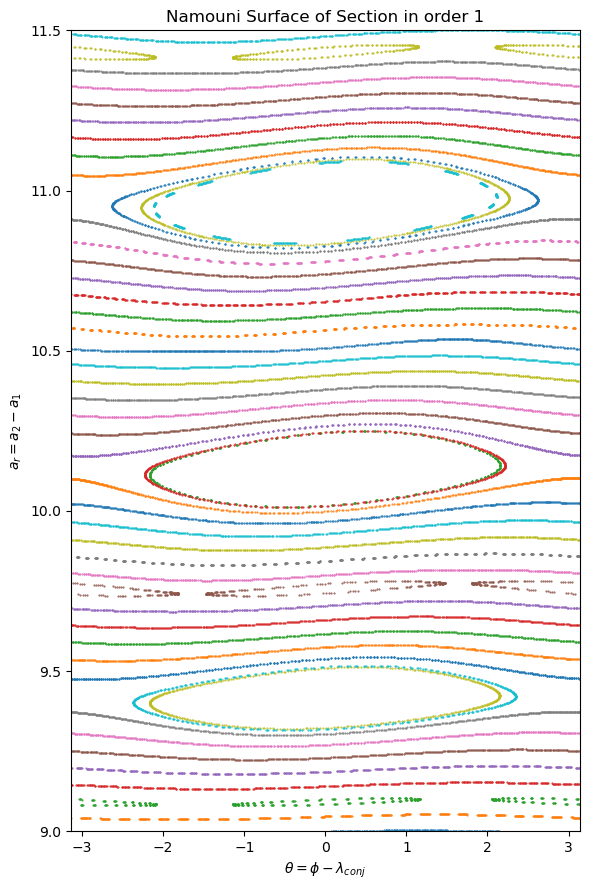

In [19]:
lambda0 = 0
phi0 = 2.1
I0 = 1**2/2 #in Namouni paper
epsilon = 5e-3  

#print(3/8*ar0_list[0]**2-I_list[0])
Na = 50 # number of original a values
ar0_list = np.linspace(9, 11.5, Na) 
#ar0_list = np.linspace(13.33447880751,  15.5, Na) # list of a = a2-a1 values
K0_list = 3/8*ar0_list**2
C = K0_list[0]-I0 # conserved quantity
I_list = K0_list - C #for the same conserved quantity
ar_conj = np.zeros((len(ar0_list), Nconj))
theta_conj = np.zeros((len(ar0_list), Nconj))
# for i, ar in enumerate(ar0_list):
#     # initial conditions
#     In = I0
#     #In=I_list[i] 
#     Kn = 3/8*ar**2
#     arn = ar
#     lambdan = lambda0
#     phin = phi0
#     # integrating
#     for j in np.arange(Nconj):
#         if j == 0 and i==0:
#             print('phin', phin)
#             print('ar_conj', arn)
#             print('lambdan', lambdan)
#             print('In', In)
#             print('Kn', Kn)
        
#         Inp1, Knp1, phinp1, lambdanp1, hnp1, knp1 = namouni_so_step(In, Kn, phin, lambdan, ar, ind)
#         thetan = (lambdan-phin)% (2*np.pi)
#         thetanp1 = (lambdanp1-phinp1) % (2*np.pi)
        
#         # if thetan > np.pi:
#         #     thetan = thetan - 2*np.pi

#         ar_conj[i, j] = arn
#         theta_conj[i, j] = thetan
#         In, Kn, phin, lambdan = Inp1, Knp1, phinp1, lambdanp1
#         arn = np.sqrt(8/3*Kn)

ar_conj = np.zeros((len(ar0_list), Nconj+1))
theta_conj = np.zeros((len(ar0_list), Nconj+1))
K_conj = np.zeros((len(ar0_list), Nconj+1))
I_conj = np.zeros((len(ar0_list), Nconj+1))
for i, ar in enumerate(ar0_list):
    I0 = I_list[i]
    # initial conditions
    K0 = 3/8*ar**2
    #integrating
    Is, Ks, phis, lambdas, hs, ks = runmap(I0, K0, phi0, lambda0, Nconj, order)
    thetas = (phis-lambdas+np.pi) % (2*np.pi) - np.pi
    #thetas = np.where(thetas>np.pi, thetas - 2*np.pi, thetas)
    ar_conj[i,:] = np.sqrt(8/3*Ks)
    theta_conj[i,:] = thetas
    I_conj[i,:] = Is
    K_conj[i,:] = Ks

#  plot
acol = ar0_list.reshape((Na, -1)) # column vector
a_arr = np.tile(acol, Nconj)
fig, ax = plt.subplots(figsize=(6,9))
ax.plot(theta_conj.T, ar_conj.T, '.', markersize=1)
ax.set_xlabel(r'$\theta = \phi- \lambda_{conj}$') 
ax.set_ylabel('$a_r = a_2 - a_1$')
ax.set_title(f'Namouni Surface of Section in order {order}')
# ax.set_xlim(-np.pi, np.pi)
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(9,11.5)
#ax.set_ylim(13.33447880751,  15.5)
#ax.axvline(.0026987345)
fig.tight_layout()

fig.savefig(f'namouni_cateye_dan_{order}o_01Hill.png')


In [27]:
In = I_list[0]
Kn = 3/8*ar0_list[0]**2
phin = phi0
lambdan = lambda0
ar0 = ar0_list[0]
Inp1, Knp1, phinp1, lambdanp1, hnp1, knp1 = namouni_10o_step(In, Kn, phin, lambdan, ar0, ind)
print(Inp1, Knp1, phinp1, lambdanp1)

24.93615588536355 63.81115588536355 0.00019029627962712382 66.5223115493591


In [14]:
# W310 = .1430675142
# W4phi = -3/8

In = I_list[0]
Kn = 3/8*ar0_list[0]**2
phin = phi0
lambdan = lambda0
ar0 = ar0_list[0]
Inp1_analytic, Knp1, phinp1, lambdanp1 = namouni_o4_step_lizzy(In, Kn, lambdan, phin, ar0)
print(Inp1_analytic, Knp1, phinp1, lambdanp1)

24.90787075946342 63.78287075946342 0.0035433604519821424 66.53654997105986


These are the values of $e_\star = e/a$, which we're expanding in powers of in Eq 15, so the fact that they're close to 1 means higher order terms are likely important

In [61]:
np.sqrt(2*I_list)/ar0_list

array([0.53846154, 0.54011385, 0.54175157, 0.54337493, 0.54498411,
       0.54657932, 0.54816075, 0.54972858, 0.55128301, 0.5528242 ,
       0.55435235, 0.55586762, 0.55737019, 0.55886022, 0.56033787,
       0.56180331, 0.5632567 , 0.56469818, 0.56612792, 0.56754606,
       0.56895274, 0.57034812, 0.57173233, 0.57310551, 0.57446779,
       0.57581932, 0.57716021, 0.57849061, 0.57981063, 0.5811204 ,
       0.58242005, 0.58370969, 0.58498944, 0.58625941, 0.58751973,
       0.58877051, 0.59001184, 0.59124385, 0.59246664, 0.59368031,
       0.59488497, 0.59608071, 0.59726765, 0.59844587, 0.59961548,
       0.60077656, 0.60192922, 0.60307354, 0.60420962, 0.60533754,
       0.6064574 , 0.60756927, 0.60867325, 0.60976942, 0.61085787,
       0.61193866, 0.61301189, 0.61407763, 0.61513597, 0.61618697,
       0.61723072, 0.61826728, 0.61929674, 0.62031916, 0.62133461,
       0.62234318, 0.62334492, 0.6243399 , 0.62532819, 0.62630987,
       0.62728498, 0.62825361, 0.62921581, 0.63017164, 0.63112

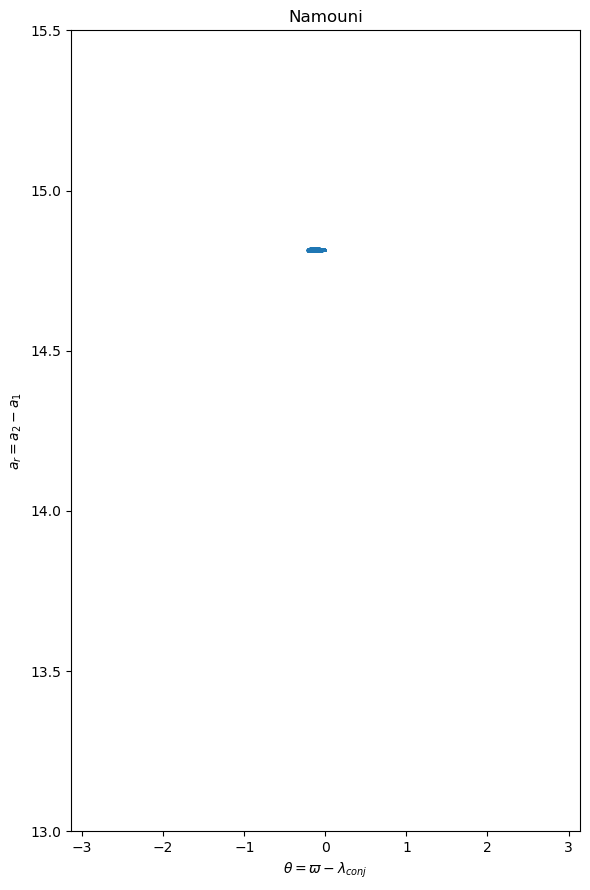

In [35]:
Na = 1 # number of original a values
ar0_list = np.array([14.815])#np.linspace(14.038, 14.1, Na) # np.linspace(13.33447880751, 13.3345, Na) # list of a = a2-a1 values
lambda0 = 0#np.pi
phi0 = 0#np.pi/2

K0_list = 3/8*ar0_list**2
I_list = K0_list - C
ar_conj = np.zeros((len(ar0_list), Nconj))
theta_conj = np.zeros((len(ar0_list), Nconj))

ar_conj = np.zeros((len(ar0_list), Nconj+1))
theta_conj = np.zeros((len(ar0_list), Nconj+1))
K_conj = np.zeros((len(ar0_list), Nconj+1))
I_conj = np.zeros((len(ar0_list), Nconj+1))
for i, ar in enumerate(ar0_list):
    I0 = I_list[i]
    # initial conditions
    K0 = 3/8*ar**2
    #integrating
    Is, Ks, phis, lambdas, hs, ks = runmap(I0, K0, phi0, lambda0, Nconj, order)
    thetas = (phis-lambdas+np.pi) % (2*np.pi) - np.pi
    #thetas = np.where(thetas>np.pi, thetas - 2*np.pi, thetas)
    ar_conj[i,:] = np.sqrt(8/3*Ks)
    theta_conj[i,:] = thetas
    I_conj[i,:] = Is
    K_conj[i,:] = Ks

#  plot
acol = ar0_list.reshape((Na, -1)) # column vector
a_arr = np.tile(acol, Nconj)
fig, ax = plt.subplots(figsize=(6,9))
ax.plot(theta_conj.T, ar_conj.T, '.', markersize=1)
ax.set_xlabel(r'$\theta = \varpi- \lambda_{conj}$') 
ax.set_ylabel('$a_r = a_2 - a_1$')
ax.set_title('Namouni')
# ax.set_xlim(-np.pi, np.pi)
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(13,15.5)
#ax.axvline(.0026987345)
fig.tight_layout()
#print((thetas[1:]-thetas[:-1])/np.pi)
#fig.savefig('namouni_cateye.png')


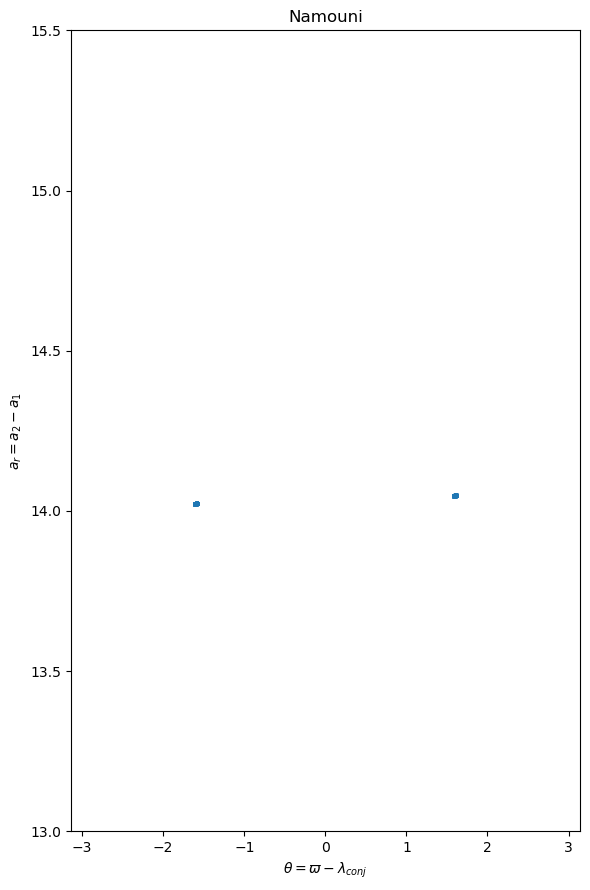

In [36]:
I0 = 7**2/2 #in Namouni paper
epsilon = 5e-3  

Na = 1 # number of original a values
ar0_list = np.array([14.0222])
lambda0 = np.pi
phi0 = np.pi/2

K0_list = 3/8*ar0_list**2
I_list = K0_list - C
ar_conj = np.zeros((len(ar0_list), Nconj))
theta_conj = np.zeros((len(ar0_list), Nconj))

ar_conj = np.zeros((len(ar0_list), Nconj+1))
theta_conj = np.zeros((len(ar0_list), Nconj+1))
K_conj = np.zeros((len(ar0_list), Nconj+1))
I_conj = np.zeros((len(ar0_list), Nconj+1))
for i, ar in enumerate(ar0_list):
    I0 = I_list[i]
    # initial conditions
    K0 = 3/8*ar**2
    #integrating
    Is, Ks, phis, lambdas, hs, ks = runmap(I0, K0, phi0, lambda0, Nconj, order)
    thetas = (phis-lambdas+np.pi) % (2*np.pi) - np.pi
    #thetas = np.where(thetas>np.pi, thetas - 2*np.pi, thetas)
    ar_conj[i,:] = np.sqrt(8/3*Ks)
    theta_conj[i,:] = thetas
    I_conj[i,:] = Is
    K_conj[i,:] = Ks

#  plot
acol = ar0_list.reshape((Na, -1)) # column vector
a_arr = np.tile(acol, Nconj)
fig, ax = plt.subplots(figsize=(6,9))
ax.plot(theta_conj.T, ar_conj.T, '.', markersize=1)
ax.set_xlabel(r'$\theta = \varpi- \lambda_{conj}$') 
ax.set_ylabel('$a_r = a_2 - a_1$')
ax.set_title('Namouni')
# ax.set_xlim(-np.pi, np.pi)
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(13,15.5)
#ax.axvline(.0026987345)
fig.tight_layout()
#print((thetas[1:]-thetas[:-1])/np.pi)
#fig.savefig('namouni_cateye.png')


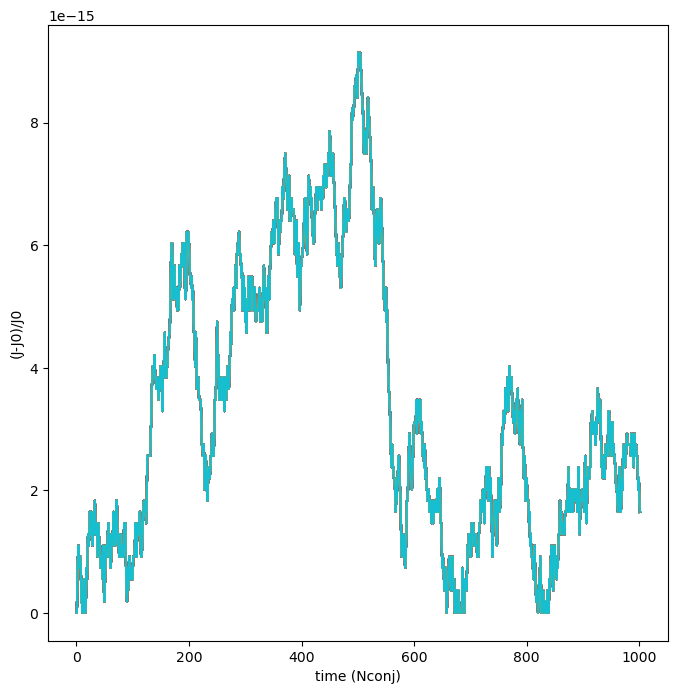

In [60]:
fig, ax = plt.subplots(figsize=(8,8))
J_conj = K_conj[i,:]-I_conj[i,:]
J0 = K_conj[0] - I_conj[0]
for i in range(len(ar0_list)):
    ax.plot(range(Nconj+1),np.abs((J_conj-J0)/J0))
ax.set_ylabel('(J-J0)/J0')
ax.set_xlabel("time (Nconj)")
plt.savefig('Jplot.png')
# ax.set_ylim(-0.0001,0.0001)

In [15]:
def namouni_fo_step_noapprox(In, Kn, phin, lambdan, arn):
    """First-order Namouni mapping step."""
    hn = np.sqrt(2*In)*np.cos(phin)
    kn = np.sqrt(2*In)*np.sin(phin)
    hprime = hn - 2*W1*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
    kprime = kn + 2*W1*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
    phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
    #print(hn, kn)
    # both options should give the same result:
    Inprime = 1/2*(hprime**2 + kprime**2)
    #Inprime = In + 2*W1/arn**2*np.sqrt(2*In)*np.sin(thetan) + 2*W1**2/arn**4
    #Namouni update
    hnp1 = hprime
    knp1 = kprime
    Inp1 = Inprime
    Knp1 = Kn + Inp1 - In
    phinp1 = phiprime
    #lambdanp1 = lambdan + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))
    
    
    lambdanp1 = lambdan + 2*np.pi*np.abs(1/((1+np.sqrt(8*Knp1/3)*epsilon)**(-3/2)-1)) #same lambda
    
    return Inp1, Knp1, phinp1, lambdanp1, hnp1, knp1



In [16]:
def namouni_fo_step_abs(e1_vec_n, e2_vec_n, a1_conj_n, a2_conj_n, lambdan_n, ind):
    #hard calculate the relative values
    #print(e1_0, e2_0, pomega1_0, pomega2_0, a1_conj_0, a2_conj_0, lambdan_0)
    
    if ind==1:
        e12_vec = e2_vec_n - e1_vec_n
        ar_n = (a2_conj_n-a1_conj_n)/a1_conj_n/epsilon
        Kn = 3*ar_n**2/8
    else:
        e12_vec = e1_vec_n - e2_vec_n
        ar_n = (a1_conj_n-a2_conj_n)/a2_conj_n/epsilon
        Kn = 3*ar_n**2/8
    
    pomega12_temp = np.angle(e12_vec)
    e12_mag = np.sqrt((np.real(e12_vec))**2+(np.imag(e12_vec))**2)
    In = (e12_mag/epsilon)**2 / 2  
    hn = np.sqrt(2*In)*np.cos(pomega12_temp)
    kn = np.sqrt(2*In)*np.sin(pomega12_temp)  
    #phi0 = pomega12_temp

    #mapping calculation
    if ind == 1:
        hnp1 = hn - 2*W1*np.sin(lambdan_n)/ar_n**2 # + for Namouni, - for pomega
        knp1 = kn + 2*W1*np.cos(lambdan_n)/ar_n**2 # - for Namouni, + for pomega
    else:
        hnp1 = hn + 2*W1*np.sin(lambdan_n)/ar_n**2 # + for Namouni, - for pomega
        knp1 = kn - 2*W1*np.cos(lambdan_n)/ar_n**2 # - for Namouni, + for pomega
    #phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
    
    # both options should give the same result:
    Inp1 = 1/2*(hnp1**2 + knp1**2)
    #Inprime = In + 2*W1/arn**2*np.sqrt(2*In)*np.sin(thetan) + 2*W1**2/arn**4
    
    #phinp1 = phiprime
    Knp1 = Kn + Inp1 - In
    lambdanp1 = lambdan_n + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))

    
    #e12np1_mag = np.sqrt(2*Inp1)*epsilon
    e12vec = hnp1*epsilon + 1j*knp1*epsilon
    
    if ind==1: #inner pair
        arnp1 = np.sqrt(8*Knp1/3)*epsilon*a1_conj_n
        e1np1 = e1_vec_n
        a1np1 = a1_conj_n
        e2np1 = e1_vec_n + e12vec
        a2np1 = a1_conj_n+arnp1
    else: #outer pair
        arnp1 = -np.sqrt(8*Knp1/3)*epsilon*a2_conj_n
        e1np1 = e2_vec_n + e12vec
        a1np1 = a2_conj_n + arnp1
        e2np1 = e2_vec_n
        a2np1 = a2_conj_n
    return e1np1, e2np1, a1np1, a2np1, lambdanp1
# optimize K and get the optimized a2 initial condition

In [17]:
def namouni_so_step_abs(e1_vec_n, e2_vec_n, a1_conj_n, a2_conj_n, lambdan_n, ind):
    #second order Namouni mapping that inputs and outputs individual values instead of the relative ones
    #hard calculate the relative values
    #print(e1_0, e2_0, pomega1_0, pomega2_0, a1_conj_0, a2_conj_0, lambdan_0)
    if ind==1:
        e12_vec = e2_vec_n - e1_vec_n
        ar_n = (a2_conj_n-a1_conj_n)/a1_conj_n/epsilon
        Kn = 3*ar_n**2/8
    else:
        e12_vec = e1_vec_n - e2_vec_n
        ar_n = (a1_conj_n-a2_conj_n)/a2_conj_n/epsilon
        Kn = 3*ar_n**2/8
    pomega12_temp = np.angle(e12_vec)
    e12_mag = np.sqrt((np.real(e12_vec))**2+(np.imag(e12_vec))**2)
    In = (e12_mag/epsilon)**2 / 2
    hn = np.sqrt(2*In)*np.cos(pomega12_temp)
    kn = np.sqrt(2*In)*np.sin(pomega12_temp)  
    #phi0 = pomega12_temp
    if ind == 1:
        hprime = hn - 2*W1*np.sin(lambdan_n)/ar_n**2 # + for Namouni, - for pomega
        kprime = kn + 2*W1*np.cos(lambdan_n)/ar_n**2 # - for Namouni, + for pomega
    else:
        hprime = hn + 2*W1*np.sin(lambdan_n)/ar_n**2 # + for Namouni, - for pomega
        kprime = kn - 2*W1*np.cos(lambdan_n)/ar_n**2 # - for Namouni, + for pomega
    phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
    thetaprime = phiprime - lambdan_n

    # A = calc_coeff(2, W2, arn, thetaprime)
    # E1 = 1/(1+A)
    # Inp1 = E1*Inprime
    hnp1 = hprime
    knp1 = kprime
    Inp1 = (0.5*(hprime**2 + kprime**2)) / (1 + 4*W2*np.sin(2*thetaprime)*2/ar_n**3)
    phinp1 = phiprime - (W200 + 2*W2*np.cos(2*thetaprime))*2/ar_n**3
    Knp1 = Kn + Inp1 - In
    lambdanp1 = lambdan_n + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))

    
    #e12np1_mag = np.sqrt(2*Inp1)*epsilon
    e12vec = hnp1*epsilon + 1j*knp1*epsilon
    if ind==1: #inner pair
        arnp1 = np.sqrt(8*Knp1/3)*epsilon*a1_conj_n
        e1np1 = e1_vec_n
        a1np1 = a1_conj_n
        e2np1 = e1_vec_n + e12vec
        a2np1 = a1_conj_n+arnp1
    else: #outer pair
        arnp1 = -np.sqrt(8*Knp1/3)*epsilon*a2_conj_n
        e1np1 = e2_vec_n + e12vec
        a1np1 = a2_conj_n + arnp1
        e2np1 = e2_vec_n
        a2np1 = a2_conj_n
    return e1np1, e2np1, a1np1, a2np1, lambdanp1
# optimize K and get the optimized a2 initial condition

In [18]:
#DQT mapping - equivalent to Namouni but not scaled to Hill's unit
def dqt_step(lambdan, zn, epsn, eps0):
    #update
    znp1 = zn + 1j*g*np.exp(1j*lambdan)/eps0**2*np.sign(eps0)*mutot #ecc vector equivalent to h,k,pomega
    epsnp1 = epsn*np.sqrt(1+4*(np.abs(znp1)**2-np.abs(zn)**2)/(3*epsn**2)) #equivalent to K
    fenp1 = np.abs(1/((1+epsnp1)**(-3/2)-1)) #equivalent to change in lambda in terms of Knp1
    lambdanp1 = lambdan + 2*np.pi*fenp1 #same lambda
    phinp1 = np.angle(znp1)
    
    return lambdanp1, znp1, epsnp1

#This function runs dqt mapping for multiple conjunctions
def runmap_dqt(lambda0, z0, eps0, Nconj):
    try:                # minimize function later passes a 1-element list, so make it work for both scalar and list
        eps0 = eps0[0]
    except:
        pass
    lambda_d, z_d, eps_d = np.zeros(Nconj+1), np.zeros(Nconj+1,dtype = 'complex_'), np.zeros(Nconj+1)
    lambda_d[0] = lambda0
    z_d[0] = z0
    eps_d[0] = eps0

    for i in range(Nconj):
        lambda_d[i+1], z_d[i+1], eps_d[i+1] = dqt_step(lambda_d[i], z_d[i], eps_d[i], eps0)
        
    return lambda_d, z_d, eps_d


In [19]:
#This function runs Namouni mapping for multiple conjunctions
#But for individual parameters
def runmap_abs(e1_vec_0, e2_vec_0, a1_conj_0, a2_conj_0, lambdan_0, Nconj, ind, order):
    try:                # minimize function later passes a 1-element list, so make it work for both scalar and list
        a1_conj_0 = a1_conj_0[0]
    except:
        pass
    e1_s, e2_s, a1_s, a2_s, lambda_s = np.zeros(Nconj+1,dtype = 'complex_'), np.zeros(Nconj+1,dtype = 'complex_'), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1)
    #print(e1_vecarr, e2_vecarr)
    e1_s[0] = e1_vec_0
    e2_s[0] = e2_vec_0
    #print(e1_s[0], e2_s[0])
    #print(a1_conj_0, a2_conj_0)
    a1_s[0] = a1_conj_0
    a2_s[0] = a2_conj_0
    lambda_s[0] = lambdan_0
    #ar0 = np.sqrt(8*K0/3)
    for i in range(Nconj):
        if order==1:
            e1_s[i+1], e2_s[i+1], a1_s[i+1], a2_s[i+1], lambda_s[i+1] = namouni_fo_step_abs(e1_s[i], e2_s[i], a1_s[i], a2_s[i], lambda_s[i], ind)
        else:
            e1_s[i+1], e2_s[i+1], a1_s[i+1], a2_s[i+1], lambda_s[i+1] = namouni_so_step_abs(e1_s[i], e2_s[i], a1_s[i], a2_s[i], lambda_s[i], ind)            

    return e1_s, e2_s, a1_s, a2_s, lambda_s

In [20]:
#running for N conjunctions
def runmap_noapprox(I0, K0, phi0, lambda0, Nconj, order):
    try:                # minimize function later passes a 1-element list, so make it work for both scalar and list
        K0 = K0[0]
    except:
        pass
    Isn, Ksn, phisn, lambdasn, hsn, ksn = np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1)
    Isn[0] = I0
    Ksn[0] = K0
    phisn[0] = phi0
    lambdasn[0] = lambda0
    ar0 = np.sqrt(8*K0/3)

    for i in range(Nconj):
        if order==1:
            Isn[i+1], Ksn[i+1], phisn[i+1], lambdasn[i+1], hsn[i+1], ksn[i+1] = namouni_fo_step_noapprox(Isn[i], Ksn[i], phisn[i], lambdasn[i], ar0)
        else:
            Isn[i+1], Ksn[i+1], phisn[i+1], lambdasn[i+1], hsn[i+1], ksn[i+1] =namouni_fo_step_noapprox(Isn[i], Ksn[i], phisn[i], lambdasn[i], ar0)

    return Isn, Ksn, phisn, lambdasn, hsn, ksn